## Week 4 — Image Classification with CIFAR-10

We're comparing three model types today — a simple ANN, a CNN, and a data-augmented CNN — all on CIFAR-10.
Nothing fancy in this section, just getting the tools in.

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


##  Loading CIFAR-10

CIFAR-10 has 60,000 32×32 color images across 10 classes. We normalize pixel values to [0, 1] — this keeps gradients from blowing up during training.

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Sample Images
Just a quick look at what we're working with.

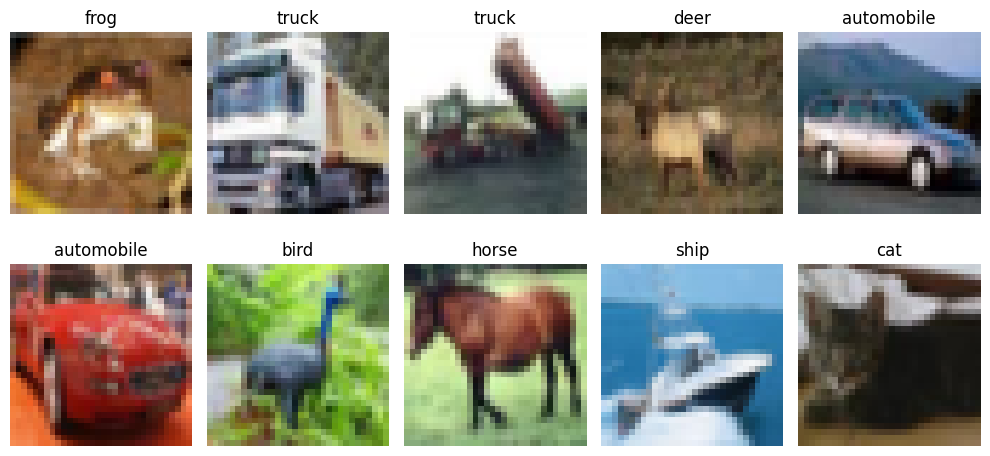

In [6]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Preprocessing
Pixel values go from 0–255 down to 0–1. ANN needs flat vectors, CNN keeps the 2D shape.

In [7]:
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("Flat shape for ANN:", x_train_flat.shape)
print("2D shape for CNN:", x_train_norm.shape)

Flat shape for ANN: (50000, 3072)
2D shape for CNN: (50000, 32, 32, 3)


## Part 1 — ANN
Flattens the image into 3072 numbers and passes through dense layers.
No spatial awareness — just a baseline to show why CNNs exist.

In [8]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="ANN")

ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

ann_model.summary()

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Accuracy: {ann_test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2656 - loss: 2.0015 - val_accuracy: 0.3292 - val_loss: 1.8702
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3116 - loss: 1.8863 - val_accuracy: 0.3506 - val_loss: 1.8173
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3312 - loss: 1.8331 - val_accuracy: 0.3770 - val_loss: 1.7617
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3440 - loss: 1.7965 - val_accuracy: 0.3874 - val_loss: 1.7600
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3521 - loss: 1.7788 - val_accuracy: 0.3930 - val_loss: 1.7333
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3630 - loss: 1.7541 - val_accuracy: 0.4062 - val_loss: 1.7095
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3673 - loss: 1.7385 - val_accuracy: 0.4046 - val_loss: 1.7163
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3724 - loss: 1.7251 - val_accuracy: 0.

## Part 2 — CNN
Uses Conv2D layers to scan the image for edges and shapes before classifying.
Filters go 32→64→128, each block finding more complex patterns than the last.

In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN")

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4538 - loss: 1.5263 - val_accuracy: 0.4934 - val_loss: 1.4079
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5982 - loss: 1.1421 - val_accuracy: 0.5968 - val_loss: 1.1288
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6619 - loss: 0.9649 - val_accuracy: 0.6588 - val_loss: 0.9983
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7042 - loss: 0.8485 - val_accuracy: 0.6774 - val_loss: 0.9296
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7360 - loss: 0.7549 - val_accuracy: 0.7140 - val_loss: 0.8453
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7663 - loss: 0.6736 - val_accuracy: 0.6462 - val_loss: 1.1083
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7910 - loss: 0.5973 - val_accuracy: 0.6860 - val_loss: 0.9752
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8050 - loss: 0.5528 - val_accuracy: 

## Validation Accuracy — ANN vs CNN
The gap here is the whole point. Same data, same epochs, very different results.

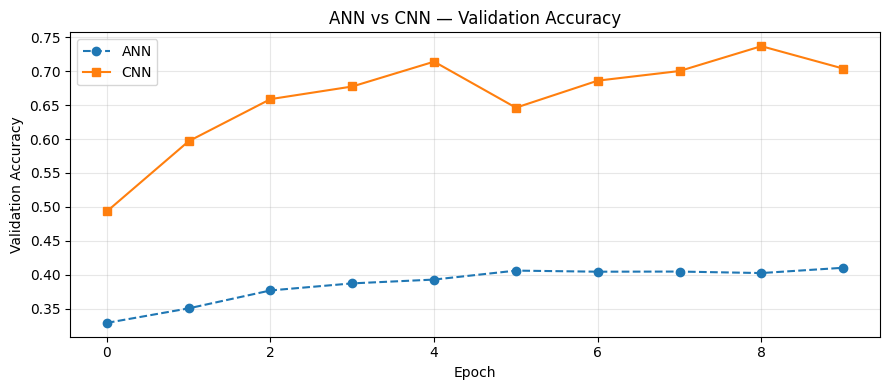

In [10]:
plt.figure(figsize=(9,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN', linestyle='--', marker='o')
plt.plot(cnn_history.history['val_accuracy'], label='CNN', linestyle='-',  marker='s')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN — Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Task 1 — More ANN Layers
Added two extra dense layers to give the ANN more capacity.
Still won't beat CNN — the problem is architecture, not depth.

In [11]:
ann_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(10,  activation='softmax')
], name="ANN_Deep")

ann_deep.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

ann_deep_history = ann_deep.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

_, ann_deep_acc = ann_deep.evaluate(x_test_flat, y_test, verbose=0)
print(f"Deep ANN Test Accuracy: {ann_deep_acc:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2352 - loss: 2.0420 - val_accuracy: 0.3100 - val_loss: 1.8957
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3020 - loss: 1.9004 - val_accuracy: 0.3348 - val_loss: 1.8201
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3194 - loss: 1.8538 - val_accuracy: 0.3542 - val_loss: 1.8134
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3299 - loss: 1.8239 - val_accuracy: 0.3598 - val_loss: 1.7749
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3417 - loss: 1.8020 - val_accuracy: 0.3778 - val_loss: 1.7526
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3433 - loss: 1.7879 - val_accuracy: 0.3994 - val_loss: 1.7210
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3548 - loss: 1.7661 - val_accuracy: 0.3950 - val_loss: 1.7005
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3615 - loss: 1.7532 - val_accuracy: 0.

## Task 2 — Deeper CNN Filters 64→128→256
Scaling up the filters gives the model more capacity to learn complex patterns.
More filters = more features detected at each layer.

In [12]:
cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN")

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,422,986 (5.43 MB)

 Trainable params: 1,422,602 (5.43 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.4953 - loss: 1.4259 - val_accuracy: 0.4148 - val_loss: 1.7964
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6360 - loss: 1.0504 - val_accuracy: 0.6526 - val_loss: 1.0034
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7026 - loss: 0.8618 - val_accuracy: 0.6476 - val_loss: 1.0376
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7451 - loss: 0.7332 - val_accuracy: 0.7182 - val_loss: 0.8401
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7827 - loss: 0.6277 - val_accuracy: 0.6892 - val_loss: 0.9215
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8161 - loss: 0.5211 - val_accuracy: 0.6946 - val_loss: 0.9206
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8401 - loss: 0.4475 - val_accuracy: 0.7122 - val_loss: 0.9207
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8693 - loss: 0.3674 - val_accuracy: 

## Task 3 — Increase Epochs to 20
Training the same CNN for 20 epochs instead of 10 to see if more training time improves accuracy.

In [13]:
cnn_20ep = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN_20epochs")

cnn_20ep.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_20ep = cnn_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

_, acc_20ep = cnn_20ep.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN (20 epochs) Test Accuracy: {acc_20ep:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4657 - loss: 1.4981 - val_accuracy: 0.5158 - val_loss: 1.3759
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6100 - loss: 1.1166 - val_accuracy: 0.5104 - val_loss: 1.5546
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6708 - loss: 0.9385 - val_accuracy: 0.5088 - val_loss: 1.6900
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7124 - loss: 0.8206 - val_accuracy: 0.6902 - val_loss: 0.8808
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7450 - loss: 0.7298 - val_accuracy: 0.6940 - val_loss: 0.8889
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7715 - loss: 0.6522 - val_accuracy: 0.6636 - val_loss: 1.0527
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7926 - loss: 0.5857 - val_accuracy: 0.6386 - val_loss: 1.2679
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8132 - loss: 0.5222 - val_accuracy: 

## Task 4 — EarlyStopping
No point training for 20 epochs if the model stops improving at epoch 13.
EarlyStopping watches val_loss and halts automatically — also restores the best weights.

In [14]:
cnn_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN_EarlyStopping")

cnn_es.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_es = cnn_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

_, acc_es = cnn_es.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN (EarlyStopping) Test Accuracy: {acc_es:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4714 - loss: 1.4872 - val_accuracy: 0.3916 - val_loss: 1.9629
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6154 - loss: 1.1010 - val_accuracy: 0.6448 - val_loss: 1.0230
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6737 - loss: 0.9363 - val_accuracy: 0.5704 - val_loss: 1.2473
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7177 - loss: 0.8148 - val_accuracy: 0.6886 - val_loss: 0.8946
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7473 - loss: 0.7260 - val_accuracy: 0.6578 - val_loss: 0.9568
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7747 - loss: 0.6437 - val_accuracy: 0.6864 - val_loss: 0.9757
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7960 - loss: 0.5759 - val_accuracy: 0.6770 - val_loss: 0.9977
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8149 - loss: 0.5219 - val_accuracy: 

## Task 5 — Data Augmentation
The model has seen every training image dozens of times — it starts memorizing instead of learning.
Augmentation randomly flips, rotates and zooms images each epoch so it never sees the exact same image twice.

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

aug_cnn = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="Augmented_CNN")

aug_cnn.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

aug_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_aug = aug_cnn.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop]
)

_, acc_aug = aug_cnn.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN Test Accuracy: {acc_aug:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.4254 - loss: 1.6388 - val_accuracy: 0.5132 - val_loss: 1.3851
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5426 - loss: 1.3010 - val_accuracy: 0.4556 - val_loss: 1.8837
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6009 - loss: 1.1559 - val_accuracy: 0.5394 - val_loss: 1.3681
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6345 - loss: 1.0613 - val_accuracy: 0.6234 - val_loss: 1.2018
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6599 - loss: 0.9958 - val_accuracy: 0.5742 - val_loss: 1.5299
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6809 - loss: 0.9391 - val_accuracy: 0.5978 - val_loss: 1.2486
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6977 - loss: 0.8906 - val_accuracy: 0.6888 - val_loss: 0.9510
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.7119 - loss: 0.8540 - va

## Final Results — All Models
Every model we built, compared. Each row represents one upgrade over the previous.

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "ANN Deep",
        "CNN (10ep)",
        "CNN (20ep)",
        "CNN + EarlyStopping",
        "CNN + Augmentation"
    ],
    "Test Accuracy": [
        round(ann_test_acc,  4),
        round(ann_deep_acc,  4),
        round(cnn_test_acc,  4),
        round(acc_20ep,      4),
        round(acc_es,        4),
        round(acc_aug,       4)
    ]
})
print(comparison.to_string(index=False))
comparison

              Model  Test Accuracy
                ANN         0.4120
           ANN Deep         0.4066
         CNN (10ep)         0.6914
         CNN (20ep)         0.7046
CNN + EarlyStopping         0.6722
 CNN + Augmentation         0.7563


,Model,Test Accuracy
0,ANN,0.4120
1,ANN Deep,0.4066
2,CNN (10ep),0.6914
3,CNN (20ep),0.7046
4,CNN + EarlyStopping,0.6722
5,CNN + Augmentation,0.7563


## All Models — Validation Accuracy Over Time
Each line is one experiment. The augmented CNN line should be the highest and most stable.

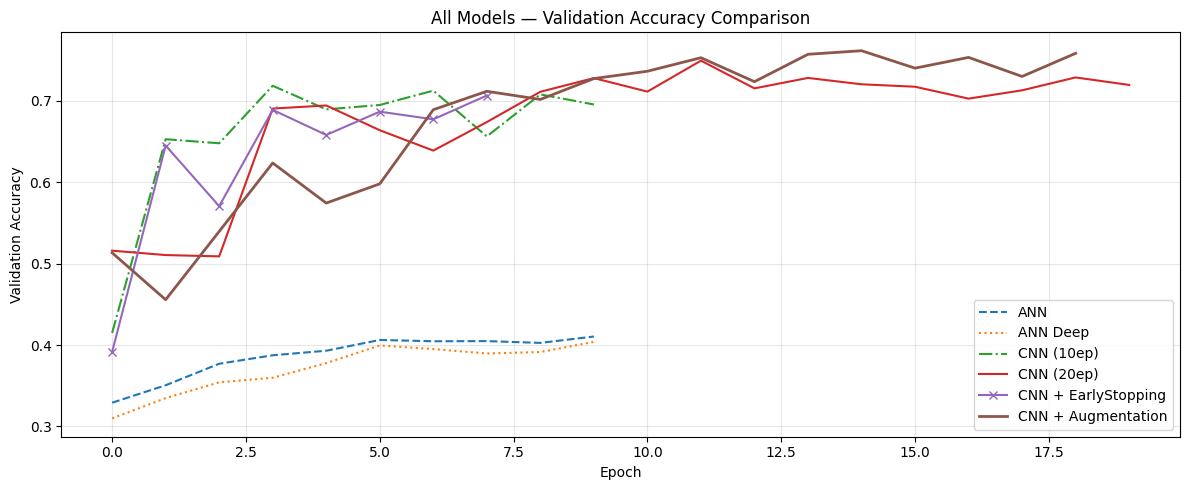

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(ann_history.history['val_accuracy'],      label='ANN',                linestyle='--')
plt.plot(ann_deep_history.history['val_accuracy'], label='ANN Deep',           linestyle=':')
plt.plot(cnn_history.history['val_accuracy'],      label='CNN (10ep)',         linestyle='-.')
plt.plot(history_20ep.history['val_accuracy'],     label='CNN (20ep)',         linestyle='-')
plt.plot(history_es.history['val_accuracy'],       label='CNN + EarlyStopping',linestyle='-', marker='x')
plt.plot(history_aug.history['val_accuracy'],      label='CNN + Augmentation', linestyle='-', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("All Models — Validation Accuracy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

**What we did:**
- Built and compared multiple models on **CIFAR-10** — 60,000 images across 10 classes
- Started with a basic **ANN**, then moved to **CNN**, then kept improving it

**What we found:**
- **ANN** flattens the image and ignores spatial structure — got around **50% accuracy**
- **CNN** uses **Conv2D layers** with filters **32→64→128** to detect edges and shapes — jumped to **70%+**
- **BatchNormalization** and **Dropout** kept the training stable and prevented memorization
- **20 epochs** gave the model more time to learn and improved results slightly
- **EarlyStopping** automatically stopped training when **val_loss** stopped improving
- **Data Augmentation** (random flips, rotations, zooms) helped the model generalize instead of memorize

**Key takeaway:**
- For images, architecture matters more than anything — a basic CNN will always beat a deep ANN
- These techniques (augmentation, early stopping, batch norm) are used in real computer vision projects too